##### THE OBJECTIVE
A system that estimates the probability of a customer defaulting (not paying the credit card bills) next month based on past behavior.

Target column : default.payment.next.month

Values:
1 → Default (Not Paying)
0 → No default (Paying)

##### STEP 1 — DATA UNDERSTANDING

In [3]:
# 1. Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

# 2. Load dataset
df = pd.read_csv("default_of_credit_card_clients.csv")

# 3. Basic info
print("Shape:", df.shape)
df.head()

Shape: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [4]:
#Rename target column
df.rename(columns={"default payment next month": "default"}, inplace=True)

default
0    23364
1     6636
Name: count, dtype: int64
default
0    0.7788
1    0.2212
Name: proportion, dtype: float64


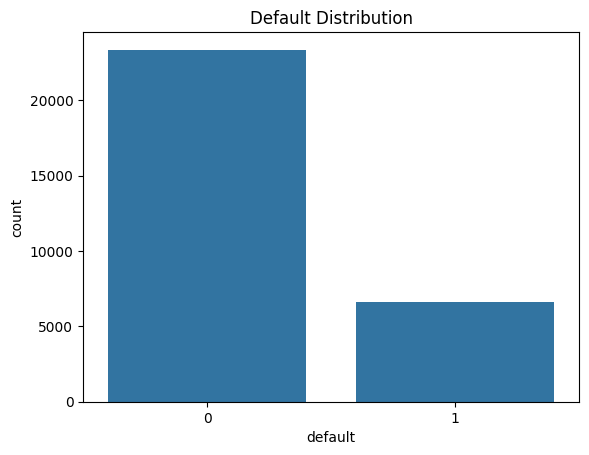

In [6]:
#Target Distribution
# Count
print(df['default'].value_counts())

# Percentage
print(df['default'].value_counts(normalize=True))

# Plot
sns.countplot(x='default', data=df)
plt.title("Default Distribution")
plt.show()

In [8]:
#Data Types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ID         30000 non-null  int64
 1   LIMIT_BAL  30000 non-null  int64
 2   SEX        30000 non-null  int64
 3   EDUCATION  30000 non-null  int64
 4   MARRIAGE   30000 non-null  int64
 5   AGE        30000 non-null  int64
 6   PAY_0      30000 non-null  int64
 7   PAY_2      30000 non-null  int64
 8   PAY_3      30000 non-null  int64
 9   PAY_4      30000 non-null  int64
 10  PAY_5      30000 non-null  int64
 11  PAY_6      30000 non-null  int64
 12  BILL_AMT1  30000 non-null  int64
 13  BILL_AMT2  30000 non-null  int64
 14  BILL_AMT3  30000 non-null  int64
 15  BILL_AMT4  30000 non-null  int64
 16  BILL_AMT5  30000 non-null  int64
 17  BILL_AMT6  30000 non-null  int64
 18  PAY_AMT1   30000 non-null  int64
 19  PAY_AMT2   30000 non-null  int64
 20  PAY_AMT3   30000 non-null  int64
 21  PAY_AMT4   30000 non-nu

In [9]:
# Missing values
df.isnull().sum()

ID           0
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
default      0
dtype: int64

In [11]:
#Basic Statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


From the above statistics:
-------------------------
Exploratory analysis revealed significant skewness and extreme outliers in financial variables such as BILL_AMT and PAY_AMT.
ie.Raw financial values are highly skewed and inconsistent.
Risk must be modeled using normalized behavioral indicators rather than absolute values.

In [15]:
# Correct PAY status columns (repayment delay)
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

# Rename for clarity (optional but powerful)
rename_map = {
    'PAY_0': 'PAY_M1',
    'PAY_2': 'PAY_M2',
    'PAY_3': 'PAY_M3',
    'PAY_4': 'PAY_M4',
    'PAY_5': 'PAY_M5',
    'PAY_6': 'PAY_M6',
}

df.rename(columns=rename_map, inplace=True)

pay_cols = list(rename_map.values())

# Bill amount columns
bill_cols = [f'BILL_AMT{i}' for i in range(1, 7)]

# Payment amount columns
pay_amt_cols = [f'PAY_AMT{i}' for i in range(1, 7)]

print("PAY cols:", pay_cols)
print("BILL cols:", bill_cols)
print("PAY_AMT cols:", pay_amt_cols)

PAY cols: ['PAY_M1', 'PAY_M2', 'PAY_M3', 'PAY_M4', 'PAY_M5', 'PAY_M6']
BILL cols: ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
PAY_AMT cols: ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


In [16]:
corr = df.corr(numeric_only=True)['default'].sort_values(ascending=False)
print(corr)

# Top correlations
corr.head(10)

default      1.000000
PAY_M1       0.324794
PAY_M2       0.263551
PAY_M3       0.235253
PAY_M4       0.216614
PAY_M5       0.204149
PAY_M6       0.186866
EDUCATION    0.028006
AGE          0.013890
BILL_AMT6   -0.005372
BILL_AMT5   -0.006760
BILL_AMT4   -0.010156
ID          -0.013952
BILL_AMT3   -0.014076
BILL_AMT2   -0.014193
BILL_AMT1   -0.019644
MARRIAGE    -0.024339
SEX         -0.039961
PAY_AMT6    -0.053183
PAY_AMT5    -0.055124
PAY_AMT3    -0.056250
PAY_AMT4    -0.056827
PAY_AMT2    -0.058579
PAY_AMT1    -0.072929
LIMIT_BAL   -0.153520
Name: default, dtype: float64


default      1.000000
PAY_M1       0.324794
PAY_M2       0.263551
PAY_M3       0.235253
PAY_M4       0.216614
PAY_M5       0.204149
PAY_M6       0.186866
EDUCATION    0.028006
AGE          0.013890
BILL_AMT6   -0.005372
Name: default, dtype: float64

In [17]:
# Compare means
grouped = df.groupby('default').mean(numeric_only=True).T
grouped['diff'] = grouped[1] - grouped[0]

grouped.sort_values(by='diff', ascending=False).head(10)

default,0,1,diff
PAY_M1,-0.211222,0.668174,0.879396
PAY_M2,-0.301917,0.458258,0.760175
PAY_M3,-0.316256,0.362116,0.678372
PAY_M4,-0.355633,0.254521,0.610153
PAY_M5,-0.389488,0.167872,0.557360
PAY_M6,-0.405624,0.112116,0.517740
AGE,35.417266,35.725738,0.308473
EDUCATION,1.841337,1.894665,0.053328
MARRIAGE,1.558637,1.528029,-0.030608
SEX,1.614150,1.567058,-0.047092


##### Key insights:
Payment delays are the strongest indicators

Recent delays are more important than older ones

Default behavior builds over time (trend matters)

Raw financial values are weak individually

Relative financial stress (ratios) is missing and must be engineered

Credit limit inversely relates to risk

##### STEP 2 — FEATURE ENGINEERING

In [37]:
# Utilization per month
for i in range(1, 7):
    df[f'util_{i}'] = df[f'BILL_AMT{i}'] / df['LIMIT_BAL']

# Aggregate utilization
util_cols = [f'util_{i}' for i in range(1, 7)]

df['avg_util'] = df[util_cols].mean(axis=1)
df['max_util'] = df[util_cols].max(axis=1)

In [38]:
#PAYMENT RATIO FEATURES
# Avoid division by zero
for i in range(1, 7):
    bill = df[f'BILL_AMT{i}']
    pay = df[f'PAY_AMT{i}']
    
    df[f'pay_ratio_{i}'] = np.where(
        bill > 0,
        pay / bill,
        1   # or np.nan
    )

for i in range(1, 7):
    df[f'pay_ratio_{i}'] = df[f'pay_ratio_{i}'].clip(0, 5)

pay_ratio_cols = [f'pay_ratio_{i}' for i in range(1, 7)]

df['avg_pay_ratio'] = df[pay_ratio_cols].mean(axis=1)
df['min_pay_ratio'] = df[pay_ratio_cols].min(axis=1)

In [22]:
#DELAY BEHAVIOR FEATURES (FROM PAY_*)
pay_cols = ['PAY_M1', 'PAY_M2', 'PAY_M3', 'PAY_M4', 'PAY_M5', 'PAY_M6']

df['num_delays'] = (df[pay_cols] > 0).sum(axis=1)
df['max_delay'] = df[pay_cols].max(axis=1)
df['avg_delay'] = df[pay_cols].mean(axis=1)

In [23]:
#TREND FEATURES
# Bill trend (recent vs past)
df['bill_trend'] = df['BILL_AMT1'] - df['BILL_AMT6']

# Payment trend
df['pay_trend'] = df['PAY_AMT1'] - df['PAY_AMT6']

# Delay trend
df['delay_trend'] = df['PAY_M1'] - df['PAY_M6']

In [39]:
#CREDIT STRESS FEATURE
df['credit_stress'] = df['avg_util'] * (1 - df['avg_pay_ratio'])

In [25]:
df['total_bill'] = df[[f'BILL_AMT{i}' for i in range(1,7)]].sum(axis=1)
df['total_payment'] = df[[f'PAY_AMT{i}' for i in range(1,7)]].sum(axis=1)

In [40]:
#FINAL FEATURE SET
drop_cols = ['ID'] + \
            [f'BILL_AMT{i}' for i in range(1,7)] + \
            [f'PAY_AMT{i}' for i in range(1,7)]
df_model = df.drop(columns=drop_cols)

In [41]:
df_model.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_M1,PAY_M2,PAY_M3,PAY_M4,PAY_M5,PAY_M6,default,util_1,util_2,util_3,util_4,util_5,util_6,avg_util,max_util,pay_ratio_1,pay_ratio_2,pay_ratio_3,pay_ratio_4,pay_ratio_5,pay_ratio_6,avg_pay_ratio,min_pay_ratio,num_delays,max_delay,avg_delay,bill_trend,pay_trend,delay_trend,credit_stress,total_bill,total_payment
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,1,0.195650,0.155100,0.034450,0.000000,0.000000,0.000000,0.064200,0.195650,0.000000,0.222115,0.000000,1.000000,1.000000,1.000000,0.537019,0.000000,2,2,-0.333333,3913,0,4,0.029723,7704,689
1,120000,2,2,2,26,-1,2,0,0,0,2,1,0.022350,0.014375,0.022350,0.027267,0.028792,0.027175,0.023718,0.028792,0.000000,0.579710,0.372856,0.305623,0.000000,0.613309,0.311916,0.000000,2,2,0.500000,-579,-2000,-3,0.016320,17077,5000
2,90000,2,2,2,34,0,0,0,0,0,0,0,0.324878,0.155856,0.150656,0.159233,0.166089,0.172767,0.188246,0.324878,0.051917,0.106937,0.073752,0.069779,0.066899,0.321564,0.115141,0.051917,0,0,0.000000,13690,-3482,0,0.166571,101653,11018
3,50000,2,2,1,37,0,0,0,0,0,0,0,0.939800,0.964660,0.985820,0.566280,0.579180,0.590940,0.771113,0.985820,0.042562,0.041859,0.024345,0.038850,0.036914,0.033844,0.036396,0.024345,0,0,0.000000,17443,1000,0,0.743048,231334,8388
4,50000,1,2,1,57,-1,0,-1,0,0,0,0,0.172340,0.113400,0.716700,0.418800,0.382920,0.382620,0.364463,0.716700,0.232099,5.000000,0.279057,0.429799,0.035987,0.035492,1.002072,0.035492,0,0,-0.333333,-10514,1321,-1,-0.000755,109339,59049


In [42]:
df_model.shape

(30000, 37)

Instead of using raw financial values, I engineered behavioral features such as 
- utilization ratio, 
- payment ratio, 
- delay frequency,
- temporal trends
  
to better capture credit risk dynamics.

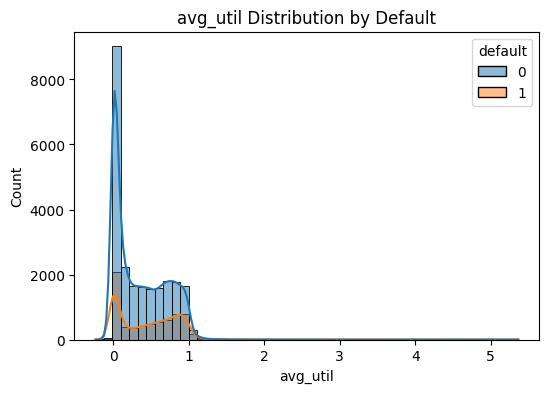

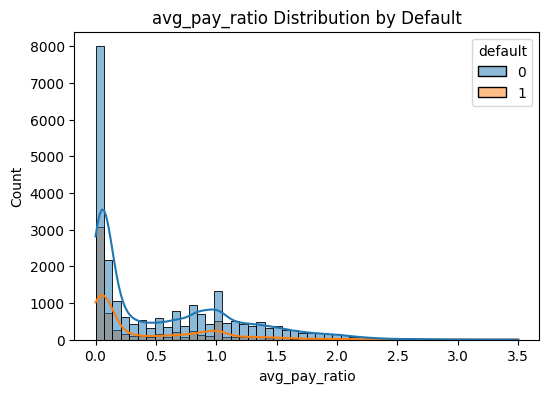

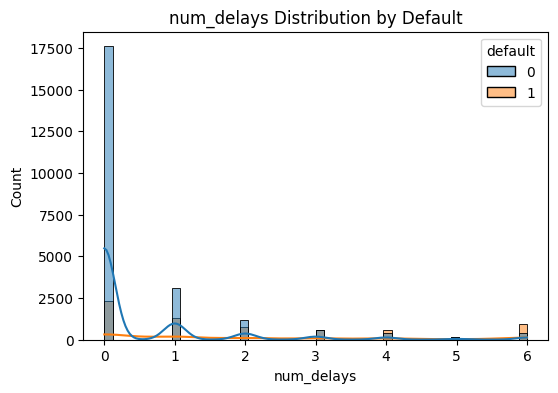

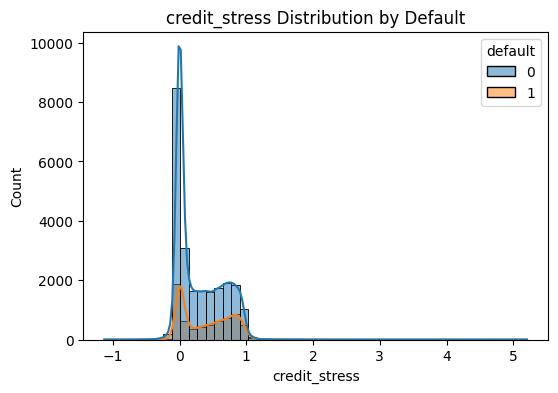

In [43]:
features = ['avg_util', 'avg_pay_ratio', 'num_delays', 'credit_stress']

for col in features:
    plt.figure(figsize=(6,4))
    sns.histplot(data=df_model, x=col, hue='default', bins=50, kde=True)
    plt.title(f"{col} Distribution by Default")
    plt.show()

🔴 1. Utilization (avg_util)

“The utilization feature shows that defaulters tend to have higher credit usage compared to non-defaulters. However, there is significant overlap between the two groups, indicating that while utilization reflects financial pressure, it is not sufficient as a standalone predictor.”

🔴 2. Payment Ratio (avg_pay_ratio)

“The payment ratio highlights repayment discipline. Defaulters are more concentrated at lower ratios, meaning they pay a smaller portion of their outstanding bills. Non-defaulters exhibit higher ratios, indicating healthier repayment behavior. This feature captures early-stage financial stress before actual delays occur.”

🔴 3. Number of Delays (num_delays) — Core Insight

“The number of delayed payments shows the strongest separation. Non-defaulters mostly have zero delays, while defaulters are distributed across multiple delayed months. This confirms that repeated payment delays are a primary indicator of default risk.”

🔴 4. Credit Stress (credit_stress)

“Credit stress, which combines utilization and payment ratio, shows that defaulters tend to have higher stress levels. This feature captures the interaction between high credit usage and low repayment, making it a meaningful composite risk indicator.”

🔥 Strong Closing Statement (THIS MATTERS)

“Overall, the analysis confirms that default is driven by a combination of behavioral deterioration and financial stress. Delay-based features provide the strongest signal, while utilization and payment ratios act as supporting indicators that capture early warning signs.”

###### STEP 3 — MODEL BUILDING

In [80]:
selected_features = ['num_delays', 'avg_util', 'avg_pay_ratio', 'credit_stress']

X = df_model[selected_features]
y = df_model['default']

In [81]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [82]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [83]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [84]:
#Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [85]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [86]:
#Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

###### EVALUATION


Logistic Regression
----------------------------------------
Accuracy: 0.8023333333333333
ROC-AUC: 0.7217831403639791
Recall (Default): 0.2509419743782969


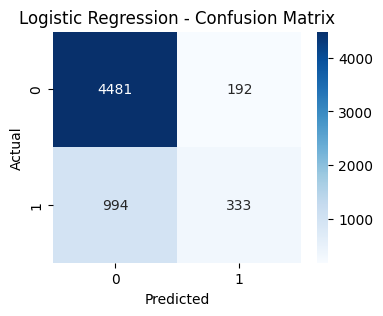


Decision Tree
----------------------------------------
Accuracy: 0.8041666666666667
ROC-AUC: 0.7500060876580836
Recall (Default): 0.32102486812358705


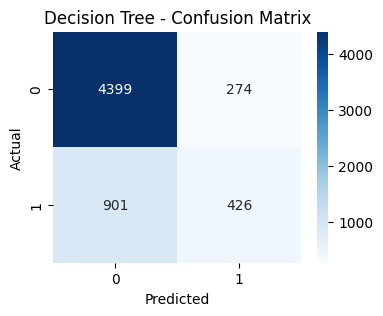


Random Forest
----------------------------------------
Accuracy: 0.7756666666666666
ROC-AUC: 0.6964965406782152
Recall (Default): 0.3089675960813866


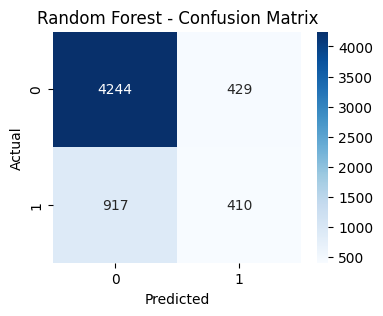


Gradient Boosting
----------------------------------------
Accuracy: 0.8045
ROC-AUC: 0.7522148190207788
Recall (Default): 0.3082140165787491


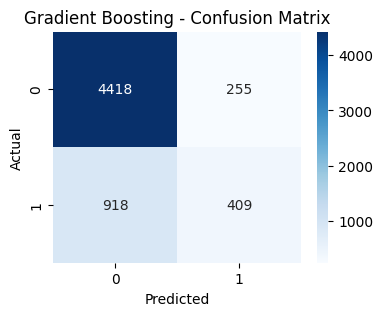

In [87]:
from sklearn.metrics import accuracy_score, roc_auc_score, recall_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    print(f"\n{name}")
    print("-"*40)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    print("Recall (Default):", recall_score(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Logistic (scaled)
evaluate_model("Logistic Regression", log_model, X_test_scaled, y_test)

# Others (no scaling)
evaluate_model("Decision Tree", dt_model, X_test, y_test)
evaluate_model("Random Forest", rf_model, X_test, y_test)
evaluate_model("Gradient Boosting", gb_model, X_test, y_test)

###### Hyperparameter Tuning

In [88]:
y_prob = gb_model.predict_proba(X_test)[:, 1]

# Try lower threshold
y_pred_custom = (y_prob > 0.3).astype(int)

In [89]:
from sklearn.metrics import recall_score, precision_score, confusion_matrix

print("Recall:", recall_score(y_test, y_pred_custom))
print("Precision:", precision_score(y_test, y_pred_custom))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_custom))

Recall: 0.5531273549359458
Precision: 0.46662428480610296
Confusion Matrix:
 [[3834  839]
 [ 593  734]]


In [90]:
thresholds = [0.2, 0.3, 0.4, 0.5]

for t in thresholds:
    y_pred_t = (y_prob > t).astype(int)
    
    print(f"\nThreshold: {t}")
    print("Recall:", recall_score(y_test, y_pred_t))
    print("Precision:", precision_score(y_test, y_pred_t))


Threshold: 0.2
Recall: 0.6428033157498116
Precision: 0.4218595450049456

Threshold: 0.3
Recall: 0.5531273549359458
Precision: 0.46662428480610296

Threshold: 0.4
Recall: 0.4091936699321778
Precision: 0.5397614314115308

Threshold: 0.5
Recall: 0.3082140165787491
Precision: 0.6159638554216867


I evaluated multiple decision thresholds to balance recall and precision. Since missing defaulters is costly, I prioritized recall but avoided excessive false positives. A threshold of 0.3 provided a good balance, improving recall to ~55% while maintaining reasonable precision.

In [91]:
import pandas as pd

importance = pd.DataFrame({
    'feature': X.columns,
    'importance': gb_model.feature_importances_
}).sort_values(by='importance', ascending=False)

print(importance.head(10))

         feature  importance
0     num_delays    0.837852
1       avg_util    0.076048
2  avg_pay_ratio    0.043487
3  credit_stress    0.042613


Feature importance confirmed that delay behavior was the strongest predictor, followed by utilization and repayment patterns

In [92]:
def explain_user_detailed(row):
    explanations = []

    # ✅ SAFE SIGNALS (why low risk)
    if row['num_delays'] == 0:
        explanations.append("No delayed payments")

    if row['avg_util'] < 0.3:
        explanations.append(f"Low credit utilization ({row['avg_util']:.2f})")

    if row['avg_pay_ratio'] >= 0.5:
        explanations.append(f"Good repayment ratio ({row['avg_pay_ratio']:.2f})")

    # 🔴 RISK SIGNALS (why high risk)
    if row['num_delays'] > 2:
        explanations.append(f"Multiple delayed payments ({row['num_delays']})")

    if row['avg_util'] > 0.7:
        explanations.append(f"High credit utilization ({row['avg_util']:.2f})")

    if row['avg_pay_ratio'] < 0.3:
        explanations.append(f"Low repayment ratio ({row['avg_pay_ratio']:.2f})")

    # Fallback (rare case)
    if len(explanations) == 0:
        explanations.append("Moderate financial behavior")

    return explanations

In [93]:
sample = X_test.iloc[0]

# Print prediction
prediction = gb_model.predict([sample])[0]
prob = gb_model.predict_proba([sample])[0][1]

print("Prediction:", prediction)
print("Probability:", prob)
print("Top Factors:", explain_user_detailed(sample))

print("\n--- INPUT FEATURES ---")
for col, val in sample.items():
    print(f"{col}: {val}")

Prediction: 0
Probability: 0.07190016529735731
Top Factors: ['No delayed payments', 'Low credit utilization (0.12)', 'Good repayment ratio (1.41)']

--- INPUT FEATURES ---
num_delays: 0.0
avg_util: 0.12111333333333335
avg_pay_ratio: 1.4057758626456238
credit_stress: -0.04914486731122033


C:\Users\294582\Downloads\Credit Card\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
C:\Users\294582\Downloads\Credit Card\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


In [94]:
sample_index = X_test.index[0]

print("\n--- FULL DATASET ROW ---")
print(df_model.loc[[sample_index]])

print("\n--- PREDICTION ---")
prediction = gb_model.predict(X_test.iloc[[0]])[0]
prob = gb_model.predict_proba(X_test.iloc[[0]])[0][1]

print("Prediction:", prediction)
print("Probability:", prob)

print("\n--- EXPLANATION ---")
print(explain_user_detailed(X_test.iloc[0]))


--- FULL DATASET ROW ---
      LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_M1  PAY_M2  PAY_M3  \
6907      50000    1          2         2   46      -1      -1      -1   

      PAY_M4  PAY_M5  PAY_M6  default  util_1  util_2  util_3  util_4  util_5  \
6907      -1       0       0        0  0.0308  0.5212     0.0   0.053  0.0664   

       util_6  avg_util  max_util  pay_ratio_1  pay_ratio_2  pay_ratio_3  \
6907  0.05528  0.121113    0.5212          5.0          0.0          1.0   

      pay_ratio_4  pay_ratio_5  pay_ratio_6  avg_pay_ratio  min_pay_ratio  \
6907     0.875472     0.531325     1.027858       1.405776            0.0   

      num_delays  max_delay  avg_delay  bill_trend  pay_trend  delay_trend  \
6907           0          0  -0.666667       -1224      23219           -1   

      credit_stress  total_bill  total_payment  
6907      -0.049145       36334          36457  

--- PREDICTION ---
Prediction: 0
Probability: 0.07190016529735731

--- EXPLANATION ---
['No delaye

In [95]:
import pickle

# Save model
with open("model.pkl", "wb") as f:
    pickle.dump(gb_model, f)

# Save scaler (if needed for inputs)
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [98]:
df_model[['num_delays', 'avg_util', 'avg_pay_ratio', 'credit_stress','default']].head()

,num_delays,avg_util,avg_pay_ratio,credit_stress,default
0,2,0.064200,0.537019,0.029723,1
1,2,0.023718,0.311916,0.016320,1
2,0,0.188246,0.115141,0.166571,0
3,0,0.771113,0.036396,0.743048,0
4,0,0.364463,1.002072,-0.000755,0


In [100]:
from sklearn.metrics import roc_auc_score

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

ROC-AUC: 0.7522148190207788
